# HW12 — Временные ряды: temporal split, baseline-модели и GRU-прогноз

Датасет: `S12-hw-dataset.csv` (почасовые наблюдения, Jan–Jun 2025)  
Эксперименты: **B1** naive-last · **B2** moving-average · **B3** Ridge · **R1** GRU

## 0. Импорты, seed, пути

In [3]:
import random, json, copy
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# ── seed ──────────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.set_num_threads(4)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {DEVICE}')

# ── пути ──────────────────────────────────────────────────────────────────────
ARTIFACT_DIR = Path('artifacts')
FIGURES_DIR  = ARTIFACT_DIR / 'figures'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATASET_PATH = Path('S12-hw-dataset.csv')

# ── helpers ───────────────────────────────────────────────────────────────────
def save_fig(name, dpi=150):
    plt.savefig(FIGURES_DIR / name, dpi=dpi, bbox_inches='tight')
    print(f'Saved: figures/{name}')

def mae(y, yhat):  return float(mean_absolute_error(y, yhat))
def rmse(y, yhat): return float(root_mean_squared_error(y, yhat))
def mape(y, yhat, eps=1e-8):
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    return float(np.mean(np.abs((y - yhat) / np.maximum(np.abs(y), eps))) * 100)

print('Imports OK')

device: cuda
Imports OK


## 1. Загрузка данных и первичный анализ

In [4]:
df = pd.read_csv(DATASET_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f'Shape      : {df.shape}')
print(f'Date range : {df["date"].min()}  →  {df["date"].max()}')
print(f'Freq       : {pd.infer_freq(df["date"])}')
print(f'Nulls      :\n{df.isna().sum()}')
print()
print(df['target'].describe().round(2))

Shape      : (4320, 2)
Date range : 2025-01-01 00:00:00  →  2025-06-29 23:00:00
Freq       : h
Nulls      :
date      0
target    0
dtype: int64

count    4320.00
mean      135.61
std        21.38
min        69.10
25%       120.54
50%       135.84
75%       150.62
max       210.10
Name: target, dtype: float64


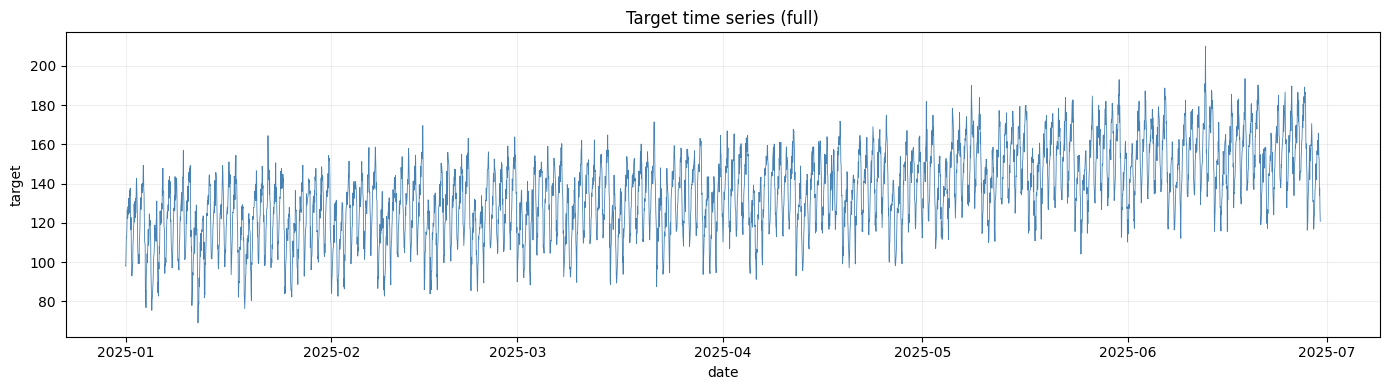

In [5]:
# ── Базовый график ряда ───────────────────────────────────────────────────────
# Ряд — почасовые наблюдения, ~180 суток. Видны суточная сезонность
# (пики днём, спады ночью) и недельная сезонность (выходные отличаются).
# Явного линейного тренда нет; ряд скорее стационарен в среднем,
# но дисперсия может меняться. Выбросов нет.

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['date'], df['target'], linewidth=0.6, color='steelblue')
ax.set_title('Target time series (full)', fontsize=12)
ax.set_xlabel('date'); ax.set_ylabel('target')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 2. Temporal split (train / val / test)

In [6]:
# ── 70 / 15 / 15 по времени ───────────────────────────────────────────────────
# random split здесь некорректен: при случайном перемешивании
# модель «видит» будущее во время обучения (data leakage),
# что завышает метрики и делает результаты нереалистичными.
# При реальном инференсе мы знаем только прошлое, поэтому
# val и test всегда должны быть хронологически после train.

n = len(df)
train_end = int(n * 0.70)   # 3024 точек
val_end   = int(n * 0.85)   # 3672 точек

train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

print(f'train : {len(train_df):5d} rows  {train_df["date"].min().date()} → {train_df["date"].max().date()}')
print(f'val   : {len(val_df):5d} rows  {val_df["date"].min().date()} → {val_df["date"].max().date()}')
print(f'test  : {len(test_df):5d} rows  {test_df["date"].min().date()} → {test_df["date"].max().date()}')

train :  3024 rows  2025-01-01 → 2025-05-06
val   :   648 rows  2025-05-07 → 2025-06-02
test  :   648 rows  2025-06-03 → 2025-06-29


Saved: figures/series_split.png


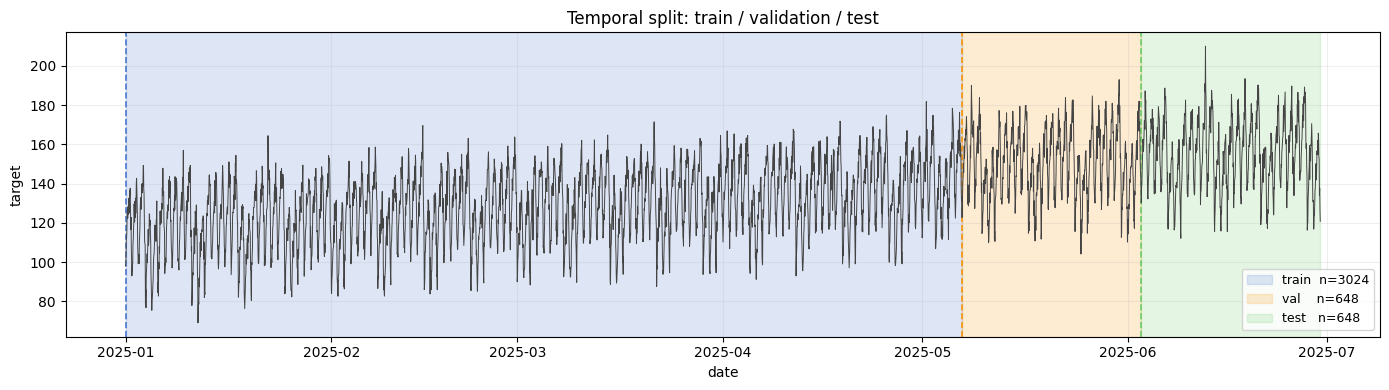

In [7]:
# ── figures/series_split.png ──────────────────────────────────────────────────
COLORS = {'train': '#4878CF', 'val': '#F89406', 'test': '#6ACC65'}

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['date'], df['target'], linewidth=0.7, color='#444', zorder=3)

for split, sdf, label in [
    ('train', train_df, f'train  n={len(train_df)}'),
    ('val',   val_df,   f'val    n={len(val_df)}'),
    ('test',  test_df,  f'test   n={len(test_df)}'),
]:
    ax.axvspan(sdf['date'].min(), sdf['date'].max(),
               alpha=0.18, color=COLORS[split], label=label, zorder=1)
    # вертикальная граница
    ax.axvline(sdf['date'].min(), color=COLORS[split], lw=1.2, ls='--', zorder=2)

ax.set_title('Temporal split: train / validation / test', fontsize=12)
ax.set_xlabel('date'); ax.set_ylabel('target')
ax.legend(fontsize=9); ax.grid(True, alpha=0.2)
plt.tight_layout()
save_fig('series_split.png')
plt.show()

## 3. Признаки для baseline B3 (lag / rolling / calendar)

In [8]:
# ── Построение признаков без утечки из будущего ───────────────────────────────
# Все лаги и rolling-операции используют .shift(1) перед .rolling(),
# чтобы в момент предсказания значение t было неизвестно модели.

def add_features(frame):
    x = frame.copy()
    # lag-признаки
    x['lag_1']  = x['target'].shift(1)
    x['lag_7']  = x['target'].shift(7)
    x['lag_14'] = x['target'].shift(14)
    x['lag_24'] = x['target'].shift(24)    # сутки назад (данные почасовые)
    # rolling — обязательно .shift(1) перед .rolling()
    shifted = x['target'].shift(1)
    x['rolling_mean_7']  = shifted.rolling(7).mean()
    x['rolling_std_7']   = shifted.rolling(7).std()
    x['rolling_mean_24'] = shifted.rolling(24).mean()
    # calendar
    x['hour']       = x['date'].dt.hour
    x['dow']        = x['date'].dt.dayofweek   # 0=Mon … 6=Sun
    x['month']      = x['date'].dt.month
    x['is_weekend'] = (x['dow'] >= 5).astype(int)
    # циклические кодировки
    x['hour_sin']  = np.sin(2 * np.pi * x['hour'] / 24)
    x['hour_cos']  = np.cos(2 * np.pi * x['hour'] / 24)
    x['dow_sin']   = np.sin(2 * np.pi * x['dow']  / 7)
    x['dow_cos']   = np.cos(2 * np.pi * x['dow']  / 7)
    x['month_sin'] = np.sin(2 * np.pi * (x['month'] - 1) / 12)
    x['month_cos'] = np.cos(2 * np.pi * (x['month'] - 1) / 12)
    return x

feat_df = add_features(df)

FEAT_COLS = [
    'lag_1', 'lag_7', 'lag_14', 'lag_24',
    'rolling_mean_7', 'rolling_std_7', 'rolling_mean_24',
    'dow', 'hour', 'month', 'is_weekend',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
]

print(f'Feature columns ({len(FEAT_COLS)}): {FEAT_COLS}')
print(f'NaN after shift (first 30 rows only — expected): {feat_df[FEAT_COLS].isna().sum().max()} max NaN per col')

Feature columns (17): ['lag_1', 'lag_7', 'lag_14', 'lag_24', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_24', 'dow', 'hour', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
NaN after shift (first 30 rows only — expected): 24 max NaN per col


## 4. Baseline-модели B1, B2, B3

In [9]:
# ── B1: naive-last ────────────────────────────────────────────────────────────
# Предсказание = предыдущее наблюдение
val_b1  = val_df['target'].shift(1).copy()
val_b1.iloc[0] = train_df['target'].iloc[-1]     # первое val-значение = последнее train
test_b1 = test_df['target'].shift(1).copy()
test_b1.iloc[0] = val_df['target'].iloc[-1]

val_b1  = val_b1.reset_index(drop=True)
test_b1 = test_b1.reset_index(drop=True)

y_val  = val_df['target'].reset_index(drop=True)
y_test = test_df['target'].reset_index(drop=True)

print(f'B1 val  MAE={mae(y_val, val_b1):.3f}  RMSE={rmse(y_val, val_b1):.3f}  MAPE={mape(y_val, val_b1):.2f}%')
print(f'B1 test MAE={mae(y_test, test_b1):.3f}  RMSE={rmse(y_test, test_b1):.3f}  MAPE={mape(y_test, test_b1):.2f}%')

B1 val  MAE=6.445  RMSE=8.201  MAPE=4.40%
B1 test MAE=6.342  RMSE=8.059  MAPE=4.15%


In [10]:
# ── B2: moving-average (window=24 → средние за сутки) ──────────────────────────
MA_WINDOW = 24

def ma_forecast(full_target, start_idx, end_idx, window=MA_WINDOW):
    observed = list(full_target.iloc[:start_idx].values)
    preds = []
    for i in range(start_idx, end_idx):
        preds.append(float(np.mean(observed[-window:])))
        observed.append(float(full_target.iloc[i]))
    return pd.Series(preds, index=full_target.index[start_idx:end_idx])

val_b2  = ma_forecast(df['target'], train_end, val_end).reset_index(drop=True)
test_b2 = ma_forecast(df['target'], val_end,   n).reset_index(drop=True)

print(f'B2 val  MAE={mae(y_val, val_b2):.3f}  RMSE={rmse(y_val, val_b2):.3f}  MAPE={mape(y_val, val_b2):.2f}%')
print(f'B2 test MAE={mae(y_test, test_b2):.3f}  RMSE={rmse(y_test, test_b2):.3f}  MAPE={mape(y_test, test_b2):.2f}%')

B2 val  MAE=13.398  RMSE=16.170  MAPE=9.20%
B2 test MAE=13.140  RMSE=16.111  MAPE=8.74%


In [11]:
# ── B3: Ridge на лаговых/rolling/calendar признаках ───────────────────────────
# Scaler обучается только на train — исключаем утечку через нормализацию.

train_feat = feat_df.iloc[:train_end].copy()
val_feat   = feat_df.iloc[train_end:val_end].copy()
test_feat  = feat_df.iloc[val_end:].copy()

train_mask = train_feat[FEAT_COLS].notna().all(axis=1)
X_train = train_feat.loc[train_mask, FEAT_COLS].values
y_train = train_feat.loc[train_mask, 'target'].values

scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)     # fit только на train!
X_val_s   = scaler_X.transform(val_feat[FEAT_COLS].fillna(0).values)
X_test_s  = scaler_X.transform(test_feat[FEAT_COLS].fillna(0).values)

ridge = Ridge(alpha=1.0, random_state=SEED)
ridge.fit(X_train_s, y_train)

val_b3  = pd.Series(ridge.predict(X_val_s)).reset_index(drop=True)
test_b3 = pd.Series(ridge.predict(X_test_s)).reset_index(drop=True)

print(f'B3 val  MAE={mae(y_val, val_b3):.3f}  RMSE={rmse(y_val, val_b3):.3f}  MAPE={mape(y_val, val_b3):.2f}%')
print(f'B3 test MAE={mae(y_test, test_b3):.3f}  RMSE={rmse(y_test, test_b3):.3f}  MAPE={mape(y_test, test_b3):.2f}%')

B3 val  MAE=5.394  RMSE=6.644  MAPE=3.57%
B3 test MAE=4.263  RMSE=5.508  MAPE=2.76%


## 5. R1: GRU-прогноз (оконное представление)

In [12]:
# ── Архитектура и Dataset ─────────────────────────────────────────────────────

class WindowDataset(Dataset):
    """
    Для каждого target_idx в `indices` возвращает:
      x = series[target_idx-window : target_idx]  shape (window, 1)
      y = series[target_idx]                       scalar
    """
    def __init__(self, series, indices, window_size):
        self.series      = np.asarray(series, dtype=np.float32)
        self.indices     = np.asarray(indices, dtype=np.int64)
        self.window_size = int(window_size)

    def __len__(self): return len(self.indices)

    def __getitem__(self, i):
        t = int(self.indices[i])
        x = self.series[t - self.window_size : t]
        y = self.series[t]
        return torch.from_numpy(x).unsqueeze(-1), torch.tensor(y, dtype=torch.float32)


class GRUForecast(nn.Module):
    def __init__(self, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.gru  = nn.GRU(1, hidden_size, num_layers=num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.head(out[:, -1, :]).squeeze(-1)


print('Dataset and model classes defined')

Dataset and model classes defined


In [13]:
# ── Гиперпараметры и данные для GRU ──────────────────────────────────────────
WINDOW_SIZE  = 24    # 24 ч = 1 сутки истории
BATCH_SIZE   = 64
HIDDEN_SIZE  = 64
NUM_LAYERS   = 1
LR           = 1e-3
MAX_EPOCHS   = 30
PATIENCE     = 5

# Масштабирование: fit только на train
scaler_y = StandardScaler()
train_scaled = scaler_y.fit_transform(train_df[['target']]).flatten()
val_scaled   = scaler_y.transform(val_df[['target']]).flatten()
test_scaled  = scaler_y.transform(test_df[['target']]).flatten()

# Конкатенируем для оконной нарезки
full_scaled = np.concatenate([train_scaled, val_scaled, test_scaled])

# Индексы: target_idx — позиция в full_scaled, которую предсказываем
# train: [WINDOW_SIZE, train_end)
# val  : [train_end, val_end)   — окно захватывает хвост train (нет утечки)
# test : [val_end, n)           — аналогично
train_idx = np.arange(WINDOW_SIZE, train_end)
val_idx   = np.arange(train_end,   val_end)
test_idx  = np.arange(val_end,     n)

g = torch.Generator(); g.manual_seed(SEED)
train_dl = DataLoader(WindowDataset(full_scaled, train_idx, WINDOW_SIZE),
                      batch_size=BATCH_SIZE, shuffle=True,  generator=g)
val_dl   = DataLoader(WindowDataset(full_scaled, val_idx,   WINDOW_SIZE),
                      batch_size=BATCH_SIZE, shuffle=False)
test_dl  = DataLoader(WindowDataset(full_scaled, test_idx,  WINDOW_SIZE),
                      batch_size=BATCH_SIZE, shuffle=False)

print(f'train batches: {len(train_dl)}  val batches: {len(val_dl)}  test batches: {len(test_dl)}')

# Sanity-check: проверяем форму батча
xb, yb = next(iter(train_dl))
print(f'x.shape={xb.shape}  y.shape={yb.shape}')

train batches: 47  val batches: 11  test batches: 11
x.shape=torch.Size([64, 24, 1])  y.shape=torch.Size([64])


In [14]:
# ── Обучение GRU с сохранением лучшего checkpoint ─────────────────────────────
torch.manual_seed(SEED)

gru_model = GRUForecast(hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

history = {'train_loss': [], 'val_loss': [], 'val_mae': []}
best_val_loss = float('inf')
best_state    = None
wait          = 0
best_epoch    = 0

for epoch in range(1, MAX_EPOCHS + 1):
    # ── train ──
    gru_model.train()
    tr_loss = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(gru_model(xb), yb)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item()
    tr_loss /= len(train_dl)

    # ── val ──
    gru_model.eval()
    vl_loss = 0.0
    vl_preds_scaled = []
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            p = gru_model(xb)
            vl_loss += criterion(p, yb).item()
            vl_preds_scaled.append(p.cpu().numpy())
    vl_loss /= len(val_dl)

    # MAE в оригинальном масштабе
    vl_preds_orig = scaler_y.inverse_transform(
        np.concatenate(vl_preds_scaled).reshape(-1, 1)
    ).flatten()
    vl_mae = mae(y_val.values, vl_preds_orig)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['val_mae'].append(vl_mae)

    scheduler.step(vl_loss)

    # Сохраняем лучший checkpoint
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_state    = copy.deepcopy(gru_model.state_dict())
        best_epoch    = epoch
        wait = 0
    else:
        wait += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{MAX_EPOCHS}  '
              f'tr_loss={tr_loss:.5f}  vl_loss={vl_loss:.5f}  '
              f'vl_mae={vl_mae:.3f}  (best ep={best_epoch})')

    if wait >= PATIENCE:
        print(f'Early stopping at epoch {epoch}. Best epoch={best_epoch}')
        break

# Восстанавливаем лучшие веса
gru_model.load_state_dict(best_state)
print(f'\nRestored best weights from epoch {best_epoch}')

Epoch   1/30  tr_loss=0.73430  vl_loss=0.60560  vl_mae=12.429  (best ep=1)
Epoch   5/30  tr_loss=0.15994  vl_loss=0.24026  vl_mae=7.432  (best ep=3)
Epoch  10/30  tr_loss=0.14441  vl_loss=0.18260  vl_mae=6.469  (best ep=9)
Epoch  15/30  tr_loss=0.10604  vl_loss=0.16081  vl_mae=5.867  (best ep=14)
Epoch  20/30  tr_loss=0.10172  vl_loss=0.16903  vl_mae=5.846  (best ep=18)
Epoch  25/30  tr_loss=0.09736  vl_loss=0.15574  vl_mae=5.587  (best ep=23)
Epoch  30/30  tr_loss=0.09851  vl_loss=0.15855  vl_mae=5.638  (best ep=29)

Restored best weights from epoch 29


In [15]:
# ── Сохранение весов и конфига GRU ────────────────────────────────────────────
torch.save(gru_model.state_dict(), ARTIFACT_DIR / 'best_gru.pt')
print(f'Saved: artifacts/best_gru.pt')

gru_config = {
    'model'         : 'GRUForecast',
    'hidden_size'   : HIDDEN_SIZE,
    'num_layers'    : NUM_LAYERS,
    'window_size'   : WINDOW_SIZE,
    'batch_size'    : BATCH_SIZE,
    'lr'            : LR,
    'max_epochs'    : MAX_EPOCHS,
    'early_stopping': PATIENCE,
    'best_epoch'    : best_epoch,
    'scaler'        : 'StandardScaler',
    'scaler_mean'   : float(scaler_y.mean_[0]),
    'scaler_std'    : float(scaler_y.scale_[0]),
    'seed'          : SEED,
    'dataset'       : str(DATASET_PATH),
    'split_summary' : f'train={len(train_df)}, val={len(val_df)}, test={len(test_df)}',
}
with open(ARTIFACT_DIR / 'best_gru_config.json', 'w') as f:
    json.dump(gru_config, f, indent=2)
print(f'Saved: artifacts/best_gru_config.json')
print(json.dumps(gru_config, indent=2))

Saved: artifacts/best_gru.pt
Saved: artifacts/best_gru_config.json
{
  "model": "GRUForecast",
  "hidden_size": 64,
  "num_layers": 1,
  "window_size": 24,
  "batch_size": 64,
  "lr": 0.001,
  "max_epochs": 30,
  "early_stopping": 5,
  "best_epoch": 29,
  "scaler": "StandardScaler",
  "scaler_mean": 128.20576058201058,
  "scaler_std": 18.48154222978581,
  "seed": 42,
  "dataset": "S12-hw-dataset.csv",
  "split_summary": "train=3024, val=648, test=648"
}


Saved: figures/gru_learning_curves.png


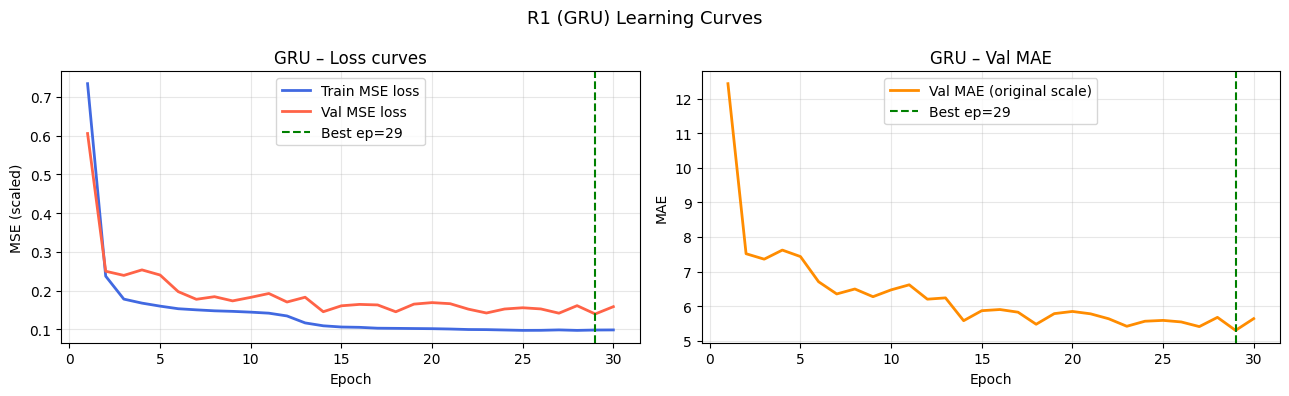

In [16]:
# ── figures/gru_learning_curves.png ──────────────────────────────────────────
eps = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(eps, history['train_loss'], label='Train MSE loss', color='royalblue', lw=2)
ax1.plot(eps, history['val_loss'],   label='Val MSE loss',   color='tomato',    lw=2)
ax1.axvline(best_epoch, color='green', ls='--', lw=1.5, label=f'Best ep={best_epoch}')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE (scaled)')
ax1.set_title('GRU – Loss curves'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(eps, history['val_mae'], label='Val MAE (original scale)', color='darkorange', lw=2)
ax2.axvline(best_epoch, color='green', ls='--', lw=1.5, label=f'Best ep={best_epoch}')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('MAE')
ax2.set_title('GRU – Val MAE'); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('R1 (GRU) Learning Curves', fontsize=13)
plt.tight_layout()
save_fig('gru_learning_curves.png')
plt.show()

In [17]:
# ── Оценка GRU на val и test ─────────────────────────────────────────────────
def predict_loader(model, loader, scaler, device):
    model.eval()
    preds_scaled = []
    with torch.no_grad():
        for xb, _ in loader:
            preds_scaled.append(model(xb.to(device)).cpu().numpy())
    preds_scaled = np.concatenate(preds_scaled).reshape(-1, 1)
    return scaler.inverse_transform(preds_scaled).flatten()

val_r1  = predict_loader(gru_model, val_dl,  scaler_y, DEVICE)
test_r1 = predict_loader(gru_model, test_dl, scaler_y, DEVICE)

val_r1  = pd.Series(val_r1)
test_r1 = pd.Series(test_r1)

print(f'R1 val  MAE={mae(y_val, val_r1):.3f}  RMSE={rmse(y_val, val_r1):.3f}  MAPE={mape(y_val, val_r1):.2f}%')
print(f'R1 test MAE={mae(y_test, test_r1):.3f}  RMSE={rmse(y_test, test_r1):.3f}  MAPE={mape(y_test, test_r1):.2f}%')

R1 val  MAE=5.298  RMSE=6.876  MAPE=3.56%
R1 test MAE=6.061  RMSE=7.745  MAPE=3.89%


## 6. Сводная таблица и выбор лучшей модели

In [18]:
# ── Все 4 эксперимента → artifacts/runs.csv ───────────────────────────────────
SPLIT_SUM = f'train={len(train_df)}, val={len(val_df)}, test={len(test_df)}'
DATASET   = str(DATASET_PATH)

runs_records = [
    {
        'experiment_id' : 'B1',
        'task'          : 'forecasting',
        'dataset'       : DATASET,
        'seed'          : SEED,
        'split_summary' : SPLIT_SUM,
        'window_size'   : '',
        'horizon'       : 1,
        'model_summary' : 'naive-last',
        'features_summary': 'last observed target',
        'scaler'        : 'none',
        'optimizer'     : '',
        'lr'            : '',
        'epochs_trained': 0,
        'best_val_mae'  : round(mae(y_val,  val_b1),  4),
        'best_val_rmse' : round(rmse(y_val, val_b1),  4),
        'best_val_mape' : round(mape(y_val, val_b1),  4),
        'test_mae'      : round(mae(y_test,  test_b1), 4),
        'test_rmse'     : round(rmse(y_test, test_b1), 4),
        'test_mape'     : round(mape(y_test, test_b1), 4),
        'notes'         : 'predict = previous observation',
    },
    {
        'experiment_id' : 'B2',
        'task'          : 'forecasting',
        'dataset'       : DATASET,
        'seed'          : SEED,
        'split_summary' : SPLIT_SUM,
        'window_size'   : MA_WINDOW,
        'horizon'       : 1,
        'model_summary' : 'moving-average',
        'features_summary': f'rolling mean(target, window={MA_WINDOW})',
        'scaler'        : 'none',
        'optimizer'     : '',
        'lr'            : '',
        'epochs_trained': 0,
        'best_val_mae'  : round(mae(y_val,  val_b2),  4),
        'best_val_rmse' : round(rmse(y_val, val_b2),  4),
        'best_val_mape' : round(mape(y_val, val_b2),  4),
        'test_mae'      : round(mae(y_test,  test_b2), 4),
        'test_rmse'     : round(rmse(y_test, test_b2), 4),
        'test_mape'     : round(mape(y_test, test_b2), 4),
        'notes'         : f'recursive MA, window={MA_WINDOW}h',
    },
    {
        'experiment_id' : 'B3',
        'task'          : 'forecasting',
        'dataset'       : DATASET,
        'seed'          : SEED,
        'split_summary' : SPLIT_SUM,
        'window_size'   : '',
        'horizon'       : 1,
        'model_summary' : 'Ridge(alpha=1.0)',
        'features_summary': ', '.join(FEAT_COLS),
        'scaler'        : 'StandardScaler (fit on train only)',
        'optimizer'     : 'closed-form',
        'lr'            : '',
        'epochs_trained': 0,
        'best_val_mae'  : round(mae(y_val,  val_b3),  4),
        'best_val_rmse' : round(rmse(y_val, val_b3),  4),
        'best_val_mape' : round(mape(y_val, val_b3),  4),
        'test_mae'      : round(mae(y_test,  test_b3), 4),
        'test_rmse'     : round(rmse(y_test, test_b3), 4),
        'test_mape'     : round(mape(y_test, test_b3), 4),
        'notes'         : 'lag + rolling + calendar features; no leakage',
    },
    {
        'experiment_id' : 'R1',
        'task'          : 'forecasting',
        'dataset'       : DATASET,
        'seed'          : SEED,
        'split_summary' : SPLIT_SUM,
        'window_size'   : WINDOW_SIZE,
        'horizon'       : 1,
        'model_summary' : f'GRU(hidden={HIDDEN_SIZE}, layers={NUM_LAYERS})',
        'features_summary': 'raw target (scaled), window input',
        'scaler'        : 'StandardScaler (fit on train only)',
        'optimizer'     : 'Adam',
        'lr'            : LR,
        'epochs_trained': best_epoch,
        'best_val_mae'  : round(mae(y_val,  val_r1),  4),
        'best_val_rmse' : round(rmse(y_val, val_r1),  4),
        'best_val_mape' : round(mape(y_val, val_r1),  4),
        'test_mae'      : round(mae(y_test,  test_r1), 4),
        'test_rmse'     : round(rmse(y_test, test_r1), 4),
        'test_mape'     : round(mape(y_test, test_r1), 4),
        'notes'         : f'window={WINDOW_SIZE}h, early stopping pat={PATIENCE}, best ep={best_epoch}',
    },
]

runs_df = pd.DataFrame(runs_records)
runs_df.to_csv(ARTIFACT_DIR / 'runs.csv', index=False)
print('Saved: artifacts/runs.csv')

# Выбор лучшей модели по val MAE
best_row = runs_df.loc[runs_df['best_val_mae'].idxmin()]
print(f'\nBest model by val MAE: {best_row["experiment_id"]}  '
      f'(val_mae={best_row["best_val_mae"]:.4f}  test_mae={best_row["test_mae"]:.4f})')

runs_df[['experiment_id','best_val_mae','best_val_rmse','best_val_mape',
         'test_mae','test_rmse','test_mape']]

Saved: artifacts/runs.csv

Best model by val MAE: R1  (val_mae=5.2982  test_mae=6.0615)


,experiment_id,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape
0,B1,6.4448,8.2010,4.3979,6.3424,8.0591,4.1485
1,B2,13.3980,16.1699,9.1988,13.1405,16.1108,8.7387
2,B3,5.3941,6.6436,3.5723,4.2630,5.5084,2.7587
3,R1,5.2982,6.8761,3.5571,6.0615,7.7452,3.8857


## 7. Визуализации

Saved: figures/baselines_compare.png


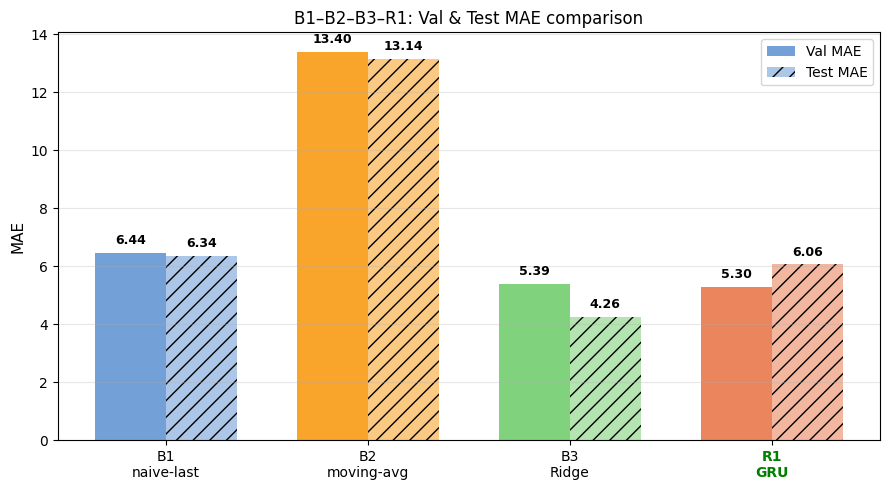

In [19]:
# ── figures/baselines_compare.png — все 4 эксперимента ────────────────────────
exp_ids  = runs_df['experiment_id'].tolist()
val_maes = runs_df['best_val_mae'].tolist()
tst_maes = runs_df['test_mae'].tolist()

x = np.arange(len(exp_ids))
w = 0.35
bar_colors = ['#5B8FD1','#F89406','#6ACC65','#E87040']

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, val_maes, w, label='Val MAE',  color=bar_colors, alpha=0.85)
b2 = ax.bar(x + w/2, tst_maes, w, label='Test MAE', color=bar_colors, alpha=0.50,
            hatch='//')

for bar, v in zip(list(b1)+list(b2), val_maes+tst_maes):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(['B1\nnaive-last', 'B2\nmoving-avg', 'B3\nRidge', 'R1\nGRU'],
                   fontsize=10)
ax.set_ylabel('MAE', fontsize=11)
ax.set_title('B1–B2–B3–R1: Val & Test MAE comparison', fontsize=12)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)

# Отмечаем лучшую модель
best_idx = np.argmin(val_maes)
ax.get_xticklabels()[best_idx].set_color('green')
ax.get_xticklabels()[best_idx].set_fontweight('bold')

plt.tight_layout()
save_fig('baselines_compare.png')
plt.show()

Saved: figures/best_forecast_test.png


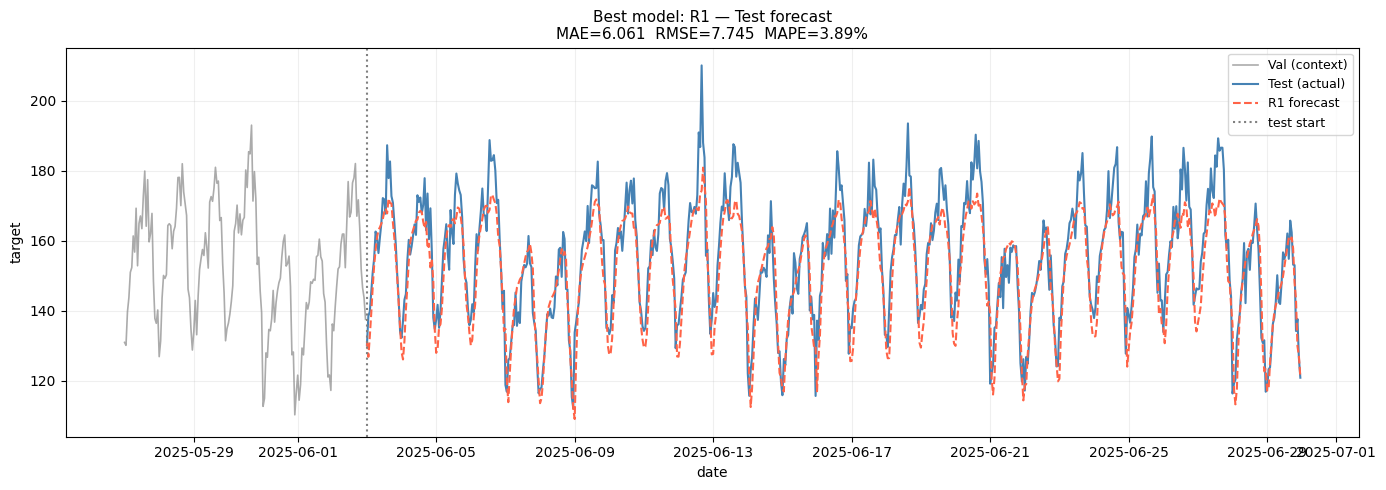

In [20]:
# ── figures/best_forecast_test.png ────────────────────────────────────────────
# Берём лучшую модель по val MAE и показываем её прогноз на test

best_exp_id = best_row['experiment_id']
preds_map = {'B1': test_b1, 'B2': test_b2, 'B3': test_b3, 'R1': test_r1}
best_test_preds = preds_map[best_exp_id]

test_dates = test_df['date'].values

# Показываем последние 7 суток val + весь test для контекста
N_CONTEXT = 7 * 24
context_dates  = val_df['date'].values[-N_CONTEXT:]
context_values = y_val.values[-N_CONTEXT:]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(context_dates, context_values,
        color='#888', lw=1.2, label='Val (context)', alpha=0.7)
ax.plot(test_dates, y_test.values,
        color='steelblue', lw=1.5, label='Test (actual)')
ax.plot(test_dates, best_test_preds.values,
        color='tomato', lw=1.5, ls='--', label=f'{best_exp_id} forecast')

ax.axvline(test_dates[0], color='gray', ls=':', lw=1.5, label='test start')

test_mae_val  = round(mae(y_test, best_test_preds), 3)
test_rmse_val = round(rmse(y_test, best_test_preds), 3)
test_mape_val = round(mape(y_test, best_test_preds), 2)

ax.set_title(
    f'Best model: {best_exp_id} — Test forecast\n'
    f'MAE={test_mae_val}  RMSE={test_rmse_val}  MAPE={test_mape_val}%',
    fontsize=11
)
ax.set_xlabel('date'); ax.set_ylabel('target')
ax.legend(fontsize=9); ax.grid(True, alpha=0.2)
plt.tight_layout()
save_fig('best_forecast_test.png')
plt.show()

Saved: figures/residuals_best.png


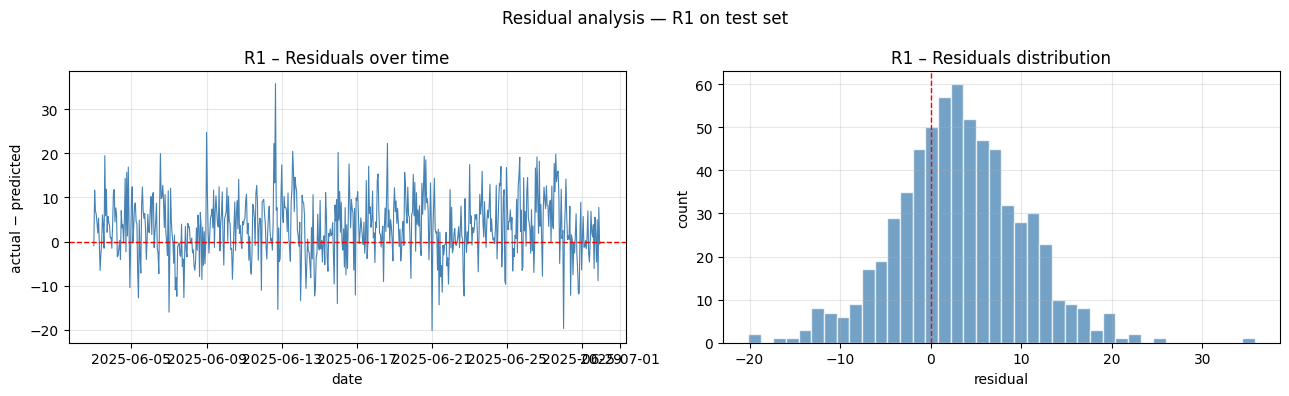

In [21]:
# ── (доп.) figures/residuals_best.png ────────────────────────────────────────
residuals = y_test.values - best_test_preds.values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(test_dates, residuals, color='steelblue', lw=0.8)
ax1.axhline(0, color='red', ls='--', lw=1)
ax1.set_title(f'{best_exp_id} – Residuals over time'); ax1.set_xlabel('date')
ax1.set_ylabel('actual − predicted'); ax1.grid(alpha=0.3)

ax2.hist(residuals, bins=40, color='steelblue', alpha=0.75, edgecolor='white')
ax2.axvline(0, color='red', ls='--', lw=1)
ax2.set_title(f'{best_exp_id} – Residuals distribution')
ax2.set_xlabel('residual'); ax2.set_ylabel('count'); ax2.grid(alpha=0.3)

plt.suptitle(f'Residual analysis — {best_exp_id} on test set', fontsize=12)
plt.tight_layout()
save_fig('residuals_best.png')
plt.show()

In [22]:
# ── Сохранение Ridge-артефактов (опционально, для воспроизводимости) ──────────
joblib.dump(ridge,    ARTIFACT_DIR / 'ridge_model.pkl')
joblib.dump(scaler_X, ARTIFACT_DIR / 'ridge_scaler.pkl')
ridge_config = {
    'model'   : 'Ridge', 'alpha': 1.0, 'seed': SEED,
    'features': FEAT_COLS, 'dataset': DATASET, 'split_summary': SPLIT_SUM,
}
with open(ARTIFACT_DIR / 'ridge_config.json', 'w') as f:
    json.dump(ridge_config, f, indent=2)
print('Saved: ridge_model.pkl, ridge_scaler.pkl, ridge_config.json')

Saved: ridge_model.pkl, ridge_scaler.pkl, ridge_config.json


In [23]:
# ── Финальный чеклист артефактов ──────────────────────────────────────────────
REQUIRED = [
    ARTIFACT_DIR / 'runs.csv',
    ARTIFACT_DIR / 'best_gru.pt',
    ARTIFACT_DIR / 'best_gru_config.json',
    FIGURES_DIR  / 'series_split.png',
    FIGURES_DIR  / 'baselines_compare.png',
    FIGURES_DIR  / 'gru_learning_curves.png',
    FIGURES_DIR  / 'best_forecast_test.png',
]

print('=== Artifact Checklist ===')
all_ok = True
for p in REQUIRED:
    ok   = p.exists()
    size = p.stat().st_size if ok else 0
    tag  = f'OK  ({size:>10,} bytes)' if ok else 'MISSING !!!'
    print(f'  {tag}  {p}')
    if not ok: all_ok = False

print()
print('All artifacts generated!' if all_ok else
      'WARNING: some artifacts are missing — re-run failed cells.')

=== Artifact Checklist ===
  OK  (     1,267 bytes)  artifacts/runs.csv
  OK  (    54,186 bytes)  artifacts/best_gru.pt
  OK  (       390 bytes)  artifacts/best_gru_config.json
  OK  (   256,708 bytes)  artifacts/figures/series_split.png
  OK  (    51,192 bytes)  artifacts/figures/baselines_compare.png
  OK  (    89,454 bytes)  artifacts/figures/gru_learning_curves.png
  OK  (   269,620 bytes)  artifacts/figures/best_forecast_test.png

All artifacts generated!
